In [1]:
%load_ext autoreload
%autoreload 2

from ageing_packages.SR_models import SR_sim, SR_plotting
from ageing_packages.utils import sr_utils as utils
from ageing_packages.hetero_analysis import correlation_analysis as ca
from ageing_packages.hetero_analysis import twin_analysis as ta
from ageing_packages.hetero_analysis import hetero_plotting as hp
from ageing_packages.hetero_analysis import survival_analysis as sa
from ageing_packages.mortality_models.gamma_gompertz import GammaGompertz as gg
from ageing_packages.mortality_data_analysis import HMD
import numpy as np
import matplotlib.pyplot as plt

def remove_top_right_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()

# Apply this to all future plots
plt.rc('axes', facecolor='white')
plt.rc('axes.spines', top=False, right=False)
plt.rc('axes', grid=False)

import pingouin as pg
import pandas as pd
from scipy import interpolate
from scipy.stats import gaussian_kde, gennorm, norm, gamma, beta
import seaborn as sns
import matplotlib.cm as cm
import sys, os, importlib, warnings, pickle
from scipy.optimize import minimize_scalar

def draw_non_negative(dist_func, size):
  dist = dist_func(size)
  mask = dist < 0
  while np.any(mask):
      dist[mask] = dist_func(np.sum(mask))
      mask = dist < 0
  return dist


In [55]:
sweden_cohort_f = HMD(country='swe', gender = 'female', data_type = 'cohort')
sweden_cohort_m = HMD(country='swe' , gender = 'male', data_type = 'cohort')
sweden_cohort_b = HMD(country='swe' , gender = 'both', data_type = 'cohort')

sweden_period_m = HMD(country='swe' , gender = 'male', data_type = 'period')
sweden_period_f = HMD(country='swe' , gender = 'female', data_type = 'period')


years = np.arange(1900, 1930, 1)

### toy example, sum of small effect alleles, gaussian + one large effect allele

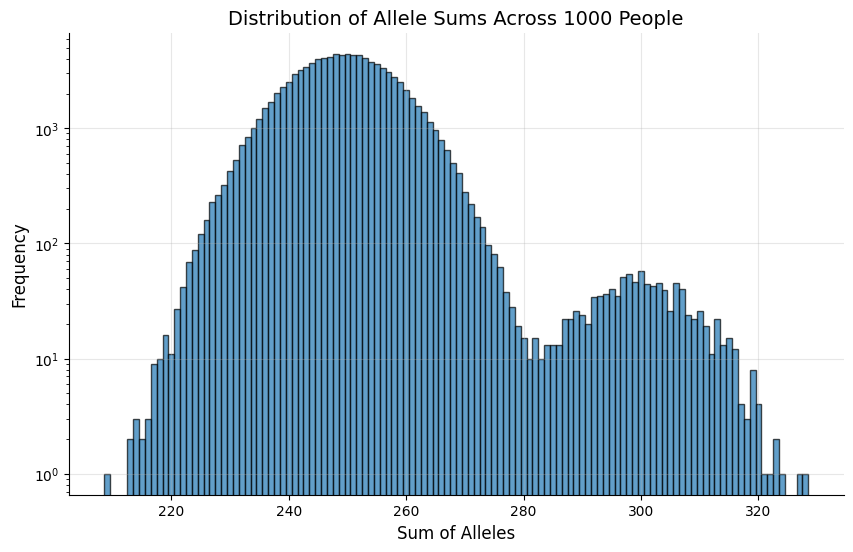

Mean sum: 249.81
Std dev: 10.32
Expected mean (sum of p_i): 249.28


In [92]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Number of alleles and people
n_alleles = 500
n_people = 100000

# Generate random probabilities p_i for each allele (uniform between 0 and 1)
p_i = np.random.uniform(0, 1, n_alleles)

# Simulate alleles for 1000 people
# Each person has 100 alleles, each allele is 0 or 1 based on its probability p_i
alleles = np.random.rand(n_people, n_alleles) < p_i

# Sum alleles for each person
allele_sums = np.sum(alleles, axis=1)


# Add a new rare allele with large effect size
# Effect size: 50, probability: 0.01
rare_allele_p = 0.01
rare_allele_effect = 50

# Simulate the rare allele for each person (1 if present, 0 if absent)
rare_allele = np.random.rand(n_people) < rare_allele_p

# Add the effect of the rare allele to allele_sums
allele_sums = allele_sums + rare_allele * rare_allele_effect


# Plot histogram
plt.figure(figsize=(10, 6))
# Use integer bins since allele_sums are integers
bins = np.arange(allele_sums.min(), allele_sums.max() + 2) - 0.5
plt.hist(allele_sums, bins=bins, edgecolor='black', alpha=0.7)
plt.xlabel('Sum of Alleles', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Allele Sums Across 1000 People', fontsize=14)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

print(f"Mean sum: {np.mean(allele_sums):.2f}")
print(f"Std dev: {np.std(allele_sums):.2f}")
print(f"Expected mean (sum of p_i): {np.sum(p_i):.2f}")


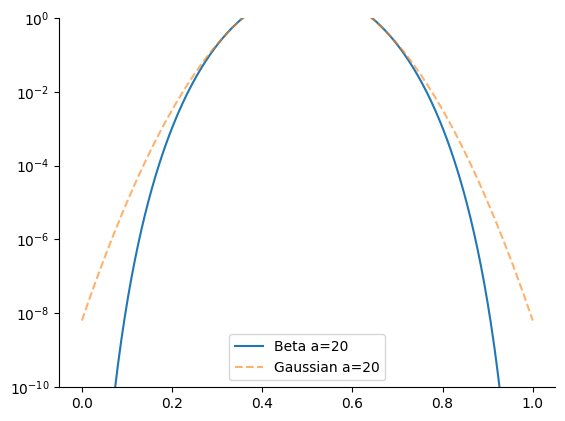

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, norm

x = np.linspace(0,1,400)
for a in [20]:
    plt.plot(x, beta.pdf(x, a,a), label=f"Beta a={a}")
    # Beta(a,a) has mean=0.5, variance=1/(4*(2a+1))
    mean = 0.5
    std = np.sqrt(1/(4*(2*a+1)))
    plt.plot(x, norm.pdf(x, mean, std), '--', alpha=0.6, label=f"Gaussian a={a}")
plt.yscale('log')
plt.ylim(1e-10, 1)
plt.legend(); plt.show()

# SR sim with t-test Xc

10
18
33
61
112
206
379
695
1274
2335
4281
7847
14384
26366
48329
88586
162377
297635
545559
Skipping population size 1000000 - larger than available data
10
18
33
61
112
206
379
695
1274
2335
4281
7847
14384
26366
48329
88586
162377
297635
545559
Skipping population size 1000000 - larger than available data
10
18
33
61
112
206
379
695
1274
2335
4281
7847
14384
26366
48329
88586
162377
297635
545559
Skipping population size 1000000 - larger than available data


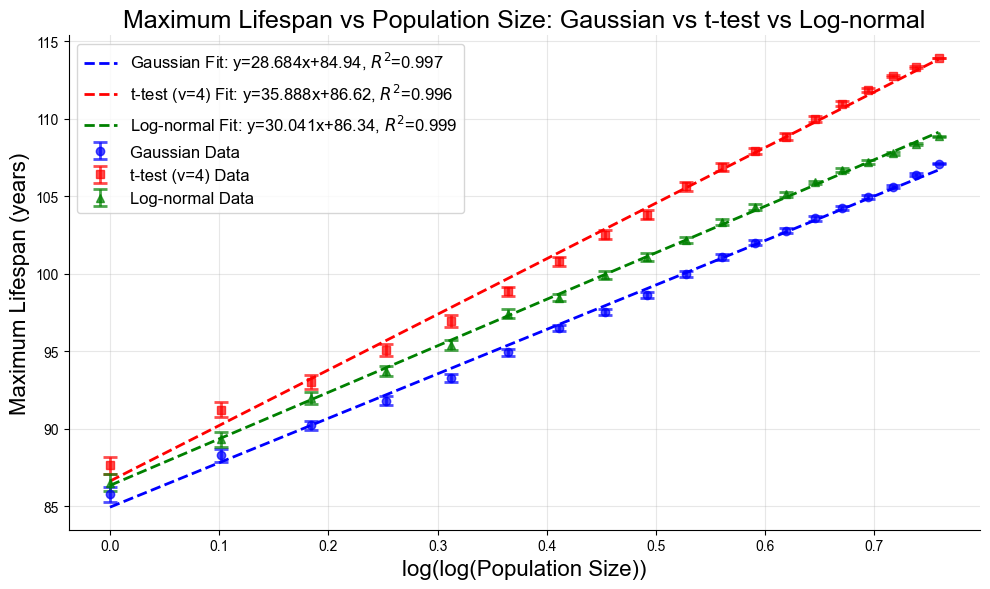

In [110]:
n_sim = int(1e6)
import sys
sys.path.append('../extrinsic_mortality_paper/data')
import model_param_calibrations as mcal

danish_dict = mcal.sr_denmark_dict.copy()
danish_Xc_std = mcal.sr_calibrations['denmark']['Xc_std']
        
# Adjust Xc
danish_dict['Xc'] = 0.85 * danish_dict['Xc']

# Define nu parameter for t-test distribution
nu = 4

# Function to run simulation and calculate max lifespans
def calculate_max_lifespans(dist_type, nu=None):
    # Create parameter distributions
    danish_param_dist = utils.create_param_distribution_dict(
        params_dict=danish_dict,
        params='Xc',
        std=danish_Xc_std,
        n=n_sim,
        family='None',
        dist_type=dist_type,
        nu=nu
    )
    
    # Simulate
    sim = utils.create_sr_simulation(params_dict=danish_param_dist, n=n_sim, parallel=True)
    
    pop_size = np.logspace(1, 6, 20)
    max_lifespans = []
    max_lifespans_sem = []
    
    death_times = sim.death_times[sim.death_times <= 130]
    shuffled_death_times = np.random.permutation(death_times)
    
    for pop in pop_size:
        pop = int(pop)
        max_values = []
        
        if pop > len(shuffled_death_times):
            print(f"Skipping population size {pop} - larger than available data")
            continue
        
        if pop == len(shuffled_death_times):
            max_values = [np.max(shuffled_death_times)]
        else:
            for i in range(100):
                max_start_idx = len(shuffled_death_times) - pop
                start_idx = (i * pop) % max_start_idx if max_start_idx > 0 else 0
                sampled_deaths = shuffled_death_times[start_idx:start_idx + pop]
                max_values.append(np.max(sampled_deaths))
        
        max_lifespans.append(np.mean(max_values))
        max_lifespans_sem.append(np.std(max_values) / np.sqrt(len(max_values)))
        print(pop)
    
    return sim, pop_size[:len(max_lifespans)], max_lifespans, max_lifespans_sem

# Run simulations for all three distributions
gaussian_sim, pop_size_gauss, max_lifespans_gauss, max_lifespans_sem_gauss = calculate_max_lifespans('gaussian')
t_sim, pop_size_t, max_lifespans_t, max_lifespans_sem_t = calculate_max_lifespans('t-test', nu=nu)
log_normal_sim, pop_size_log, max_lifespans_log, max_lifespans_sem_log = calculate_max_lifespans('lognormal')

# Store t_sim as hum_sim for compatibility with later cells
hum_sim = t_sim

# Plotting
import matplotlib.font_manager as fm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

plt.rcParams['font.family'] = 'Arial'

fig, ax = plt.subplots(figsize=(10, 6))

# Function to fit and plot
def fit_and_plot(pop_size, max_lifespans, max_lifespans_sem, label, color, marker):
    x_array = np.log10(np.log10(pop_size))
    y_array = np.array(max_lifespans)
    yerr_array = np.array(max_lifespans_sem)
    
    # Linear regression
    X = x_array.reshape(-1, 1)
    reg = LinearRegression()
    reg.fit(X, y_array)
    y_pred = reg.predict(X)
    r2 = r2_score(y_array, y_pred)
    
    slope = reg.coef_[0]
    intercept = reg.intercept_
    
    # Plot data
    ax.errorbar(x_array, y_array, yerr=yerr_array, 
                marker=marker, capsize=5, capthick=2, linewidth=2, 
                label=f'{label} Data', linestyle='None', color=color, alpha=0.7)
    
    # Plot regression line
    x_fit = np.linspace(x_array.min(), x_array.max(), 100)
    y_fit = reg.predict(x_fit.reshape(-1, 1))
    ax.plot(x_fit, y_fit, color=color, linewidth=2, linestyle='--',
            label=f'{label} Fit: y={slope:.3f}x+{intercept:.2f}, $R^2$={r2:.3f}')
    
    return slope, intercept, r2

# Fit and plot all three distributions
fit_and_plot(pop_size_gauss, max_lifespans_gauss, max_lifespans_sem_gauss, 
             'Gaussian', 'blue', 'o')
fit_and_plot(pop_size_t, max_lifespans_t, max_lifespans_sem_t, 
             f't-test (ν={nu})', 'red', 's')
fit_and_plot(pop_size_log, max_lifespans_log, max_lifespans_sem_log, 
             'Log-normal', 'green', '^')

ax.set_xlabel('log(log(Population Size))', fontsize=16)
ax.set_ylabel('Maximum Lifespan (years)', fontsize=16)
ax.set_title('Maximum Lifespan vs Population Size: Gaussian vs t-test vs Log-normal', fontsize=18)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12, loc='best')

plt.tight_layout()
plt.show()


In [99]:
log_normal_sim, pop_size_log, max_lifespans_log, max_lifespans_sem_log = calculate_max_lifespans('lognormal')


10
18
33
61
112
206
379
695
1274
2335
4281
7847
14384
26366
48329
88586
162377
297635
545559
Skipping population size 1000000 - larger than available data


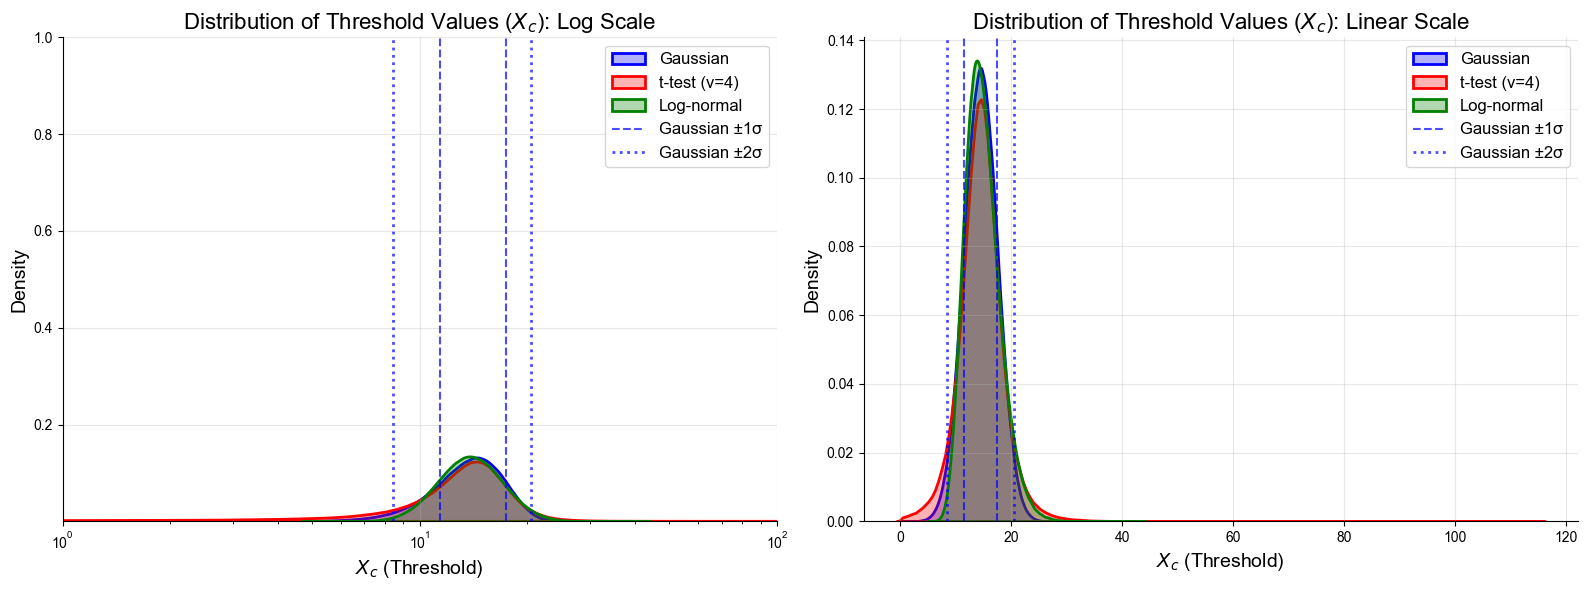

In [115]:
# Plot KDE of Xc values for all three distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Log scale
# Plot KDE for Gaussian distribution
sns.kdeplot(gaussian_sim.params.Xc, ax=ax1, color='blue', linewidth=2, 
            label='Gaussian', fill=True, alpha=0.3)

# Plot KDE for t-test distribution
sns.kdeplot(t_sim.params.Xc, ax=ax1, color='red', linewidth=2, 
            label=f't-test (ν={nu})', fill=True, alpha=0.3)

# Plot KDE for log-normal distribution
sns.kdeplot(log_normal_sim.params.Xc, ax=ax1, color='green', linewidth=2, 
            label='Log-normal', fill=True, alpha=0.3)

# Add dashed lines at mean ± sigma and ± 2*sigma for Gaussian distribution
gaussian_mean = np.mean(gaussian_sim.params.Xc)
gaussian_std = np.std(gaussian_sim.params.Xc)

# ± 1 sigma lines (dashed)
ax1.axvline(gaussian_mean - gaussian_std, color='blue', linestyle='--', linewidth=1.5, alpha=0.7, 
           label='Gaussian ±1σ')
ax1.axvline(gaussian_mean + gaussian_std, color='blue', linestyle='--', linewidth=1.5, alpha=0.7)

# ± 2 sigma lines (dotted)
ax1.axvline(gaussian_mean - 2*gaussian_std, color='blue', linestyle=':', linewidth=2, alpha=0.7,
           label='Gaussian ±2σ')
ax1.axvline(gaussian_mean + 2*gaussian_std, color='blue', linestyle=':', linewidth=2, alpha=0.7)

ax1.set_xlabel('$X_c$ (Threshold)', fontsize=14)
ax1.set_ylabel('Density', fontsize=14)
ax1.set_title('Distribution of Threshold Values ($X_c$): Log Scale', fontsize=16)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(1e-6, 1)
ax1.set_xscale('log')
ax1.set_xlim(1, 100)

# Right plot: Linear scale
# Plot KDE for Gaussian distribution
sns.kdeplot(gaussian_sim.params.Xc, ax=ax2, color='blue', linewidth=2, 
            label='Gaussian', fill=True, alpha=0.3)

# Plot KDE for t-test distribution
sns.kdeplot(t_sim.params.Xc, ax=ax2, color='red', linewidth=2, 
            label=f't-test (ν={nu})', fill=True, alpha=0.3)

# Plot KDE for log-normal distribution
sns.kdeplot(log_normal_sim.params.Xc, ax=ax2, color='green', linewidth=2, 
            label='Log-normal', fill=True, alpha=0.3)

# Add dashed lines at mean ± sigma and ± 2*sigma for Gaussian distribution
# ± 1 sigma lines (dashed)
ax2.axvline(gaussian_mean - gaussian_std, color='blue', linestyle='--', linewidth=1.5, alpha=0.7, 
           label='Gaussian ±1σ')
ax2.axvline(gaussian_mean + gaussian_std, color='blue', linestyle='--', linewidth=1.5, alpha=0.7)

# ± 2 sigma lines (dotted)
ax2.axvline(gaussian_mean - 2*gaussian_std, color='blue', linestyle=':', linewidth=2, alpha=0.7,
           label='Gaussian ±2σ')
ax2.axvline(gaussian_mean + 2*gaussian_std, color='blue', linestyle=':', linewidth=2, alpha=0.7)

ax2.set_xlabel('$X_c$ (Threshold)', fontsize=14)
ax2.set_ylabel('Density', fontsize=14)
ax2.set_title('Distribution of Threshold Values ($X_c$): Linear Scale', fontsize=16)
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


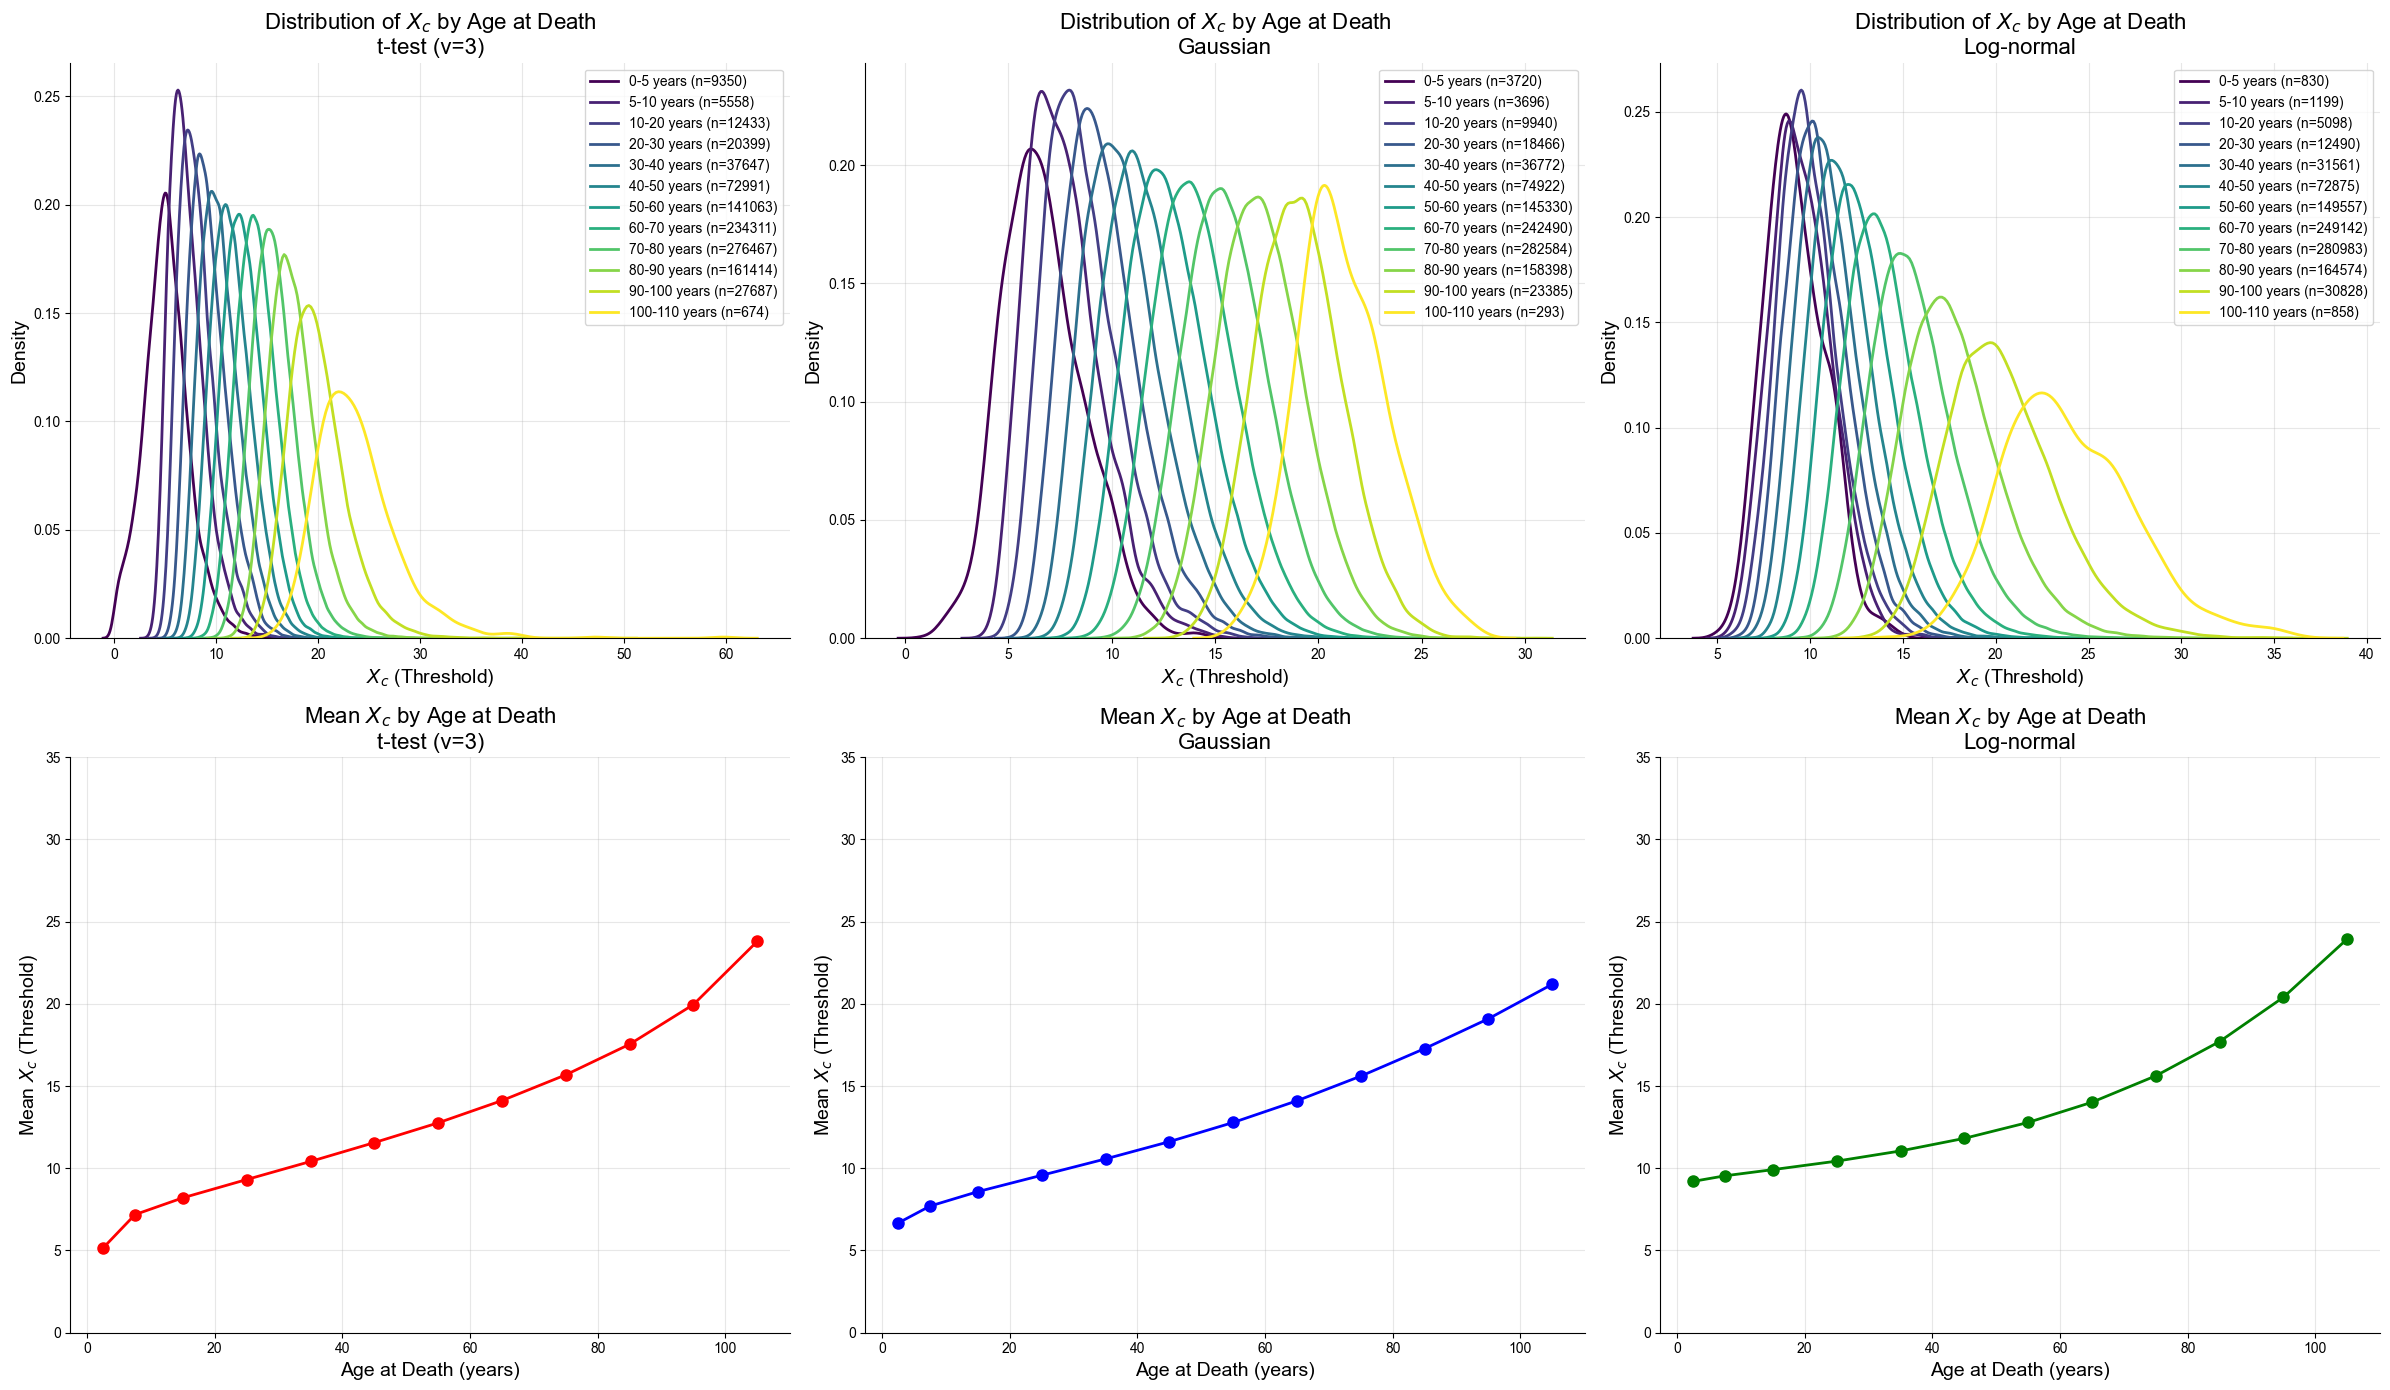

In [101]:
# Define age intervals
age_intervals = [(0, 5), (5, 10), (10, 20), (20, 30), (30, 40), (40, 50), 
                 (50, 60), (60, 70), (70, 80), (80, 90), (90, 100), (100, 110)]

# Create figure with six subplots (2x3 grid)
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(24, 14))

# Color palette
colors = plt.cm.viridis(np.linspace(0, 1, len(age_intervals)))

# Plot kernel density for each age interval - t-test distribution (top left)
for i, (age_min, age_max) in enumerate(age_intervals):
    # Find indices of deaths in this interval
    indices = np.where((t_sim.death_times >= age_min) & (t_sim.death_times < age_max))[0]
    
    if len(indices) > 0:
        # Get Xc values for these deaths
        xc_values = t_sim.params.Xc[indices]
        
        # Plot kernel density estimate
        sns.kdeplot(xc_values, ax=ax1, color=colors[i], linewidth=2, 
                    label=f'{age_min}-{age_max} years (n={len(indices)})')

ax1.set_xlabel('$X_c$ (Threshold)', fontsize=14)
ax1.set_ylabel('Density', fontsize=14)
ax1.set_title('Distribution of $X_c$ by Age at Death\nt-test (ν=3)', fontsize=16)
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, alpha=0.3)

# Plot kernel density for each age interval - Gaussian distribution (top middle)
for i, (age_min, age_max) in enumerate(age_intervals):
    # Find indices of deaths in this interval
    indices = np.where((gaussian_sim.death_times >= age_min) & (gaussian_sim.death_times < age_max))[0]
    
    if len(indices) > 0:
        # Get Xc values for these deaths
        xc_values = gaussian_sim.params.Xc[indices]
        
        # Plot kernel density estimate
        sns.kdeplot(xc_values, ax=ax2, color=colors[i], linewidth=2, 
                    label=f'{age_min}-{age_max} years (n={len(indices)})')

ax2.set_xlabel('$X_c$ (Threshold)', fontsize=14)
ax2.set_ylabel('Density', fontsize=14)
ax2.set_title('Distribution of $X_c$ by Age at Death\nGaussian', fontsize=16)
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, alpha=0.3)

# Plot kernel density for each age interval - Log-normal distribution (top right)
for i, (age_min, age_max) in enumerate(age_intervals):
    # Find indices of deaths in this interval
    indices = np.where((log_normal_sim.death_times >= age_min) & (log_normal_sim.death_times < age_max))[0]
    
    if len(indices) > 0:
        # Get Xc values for these deaths
        xc_values = log_normal_sim.params.Xc[indices]
        
        # Plot kernel density estimate
        sns.kdeplot(xc_values, ax=ax3, color=colors[i], linewidth=2, 
                    label=f'{age_min}-{age_max} years (n={len(indices)})')

ax3.set_xlabel('$X_c$ (Threshold)', fontsize=14)
ax3.set_ylabel('Density', fontsize=14)
ax3.set_title('Distribution of $X_c$ by Age at Death\nLog-normal', fontsize=16)
ax3.legend(fontsize=10, loc='best')
ax3.grid(True, alpha=0.3)

# Plot mean Xc vs age bin - t-test distribution (bottom left)
mean_xc_t = []
bin_centers = []
for age_min, age_max in age_intervals:
    indices = np.where((t_sim.death_times >= age_min) & (t_sim.death_times < age_max))[0]
    if len(indices) > 0:
        mean_xc_t.append(np.mean(t_sim.params.Xc[indices]))
        bin_centers.append((age_min + age_max) / 2)

ax4.plot(bin_centers, mean_xc_t, 'o-', color='red', linewidth=2, markersize=8)
ax4.set_xlabel('Age at Death (years)', fontsize=14)
ax4.set_ylabel('Mean $X_c$ (Threshold)', fontsize=14)
ax4.set_title('Mean $X_c$ by Age at Death\nt-test (ν=3)', fontsize=16)
ax4.set_ylim(0, 35)
ax4.grid(True, alpha=0.3)

# Plot mean Xc vs age bin - Gaussian distribution (bottom middle)
mean_xc_gauss = []
bin_centers_gauss = []
for age_min, age_max in age_intervals:
    indices = np.where((gaussian_sim.death_times >= age_min) & (gaussian_sim.death_times < age_max))[0]
    if len(indices) > 0:
        mean_xc_gauss.append(np.mean(gaussian_sim.params.Xc[indices]))
        bin_centers_gauss.append((age_min + age_max) / 2)

ax5.plot(bin_centers_gauss, mean_xc_gauss, 'o-', color='blue', linewidth=2, markersize=8)
ax5.set_xlabel('Age at Death (years)', fontsize=14)
ax5.set_ylabel('Mean $X_c$ (Threshold)', fontsize=14)
ax5.set_title('Mean $X_c$ by Age at Death\nGaussian', fontsize=16)
ax5.set_ylim(0, 35)
ax5.grid(True, alpha=0.3)

# Plot mean Xc vs age bin - Log-normal distribution (bottom right)
mean_xc_log = []
bin_centers_log = []
for age_min, age_max in age_intervals:
    indices = np.where((log_normal_sim.death_times >= age_min) & (log_normal_sim.death_times < age_max))[0]
    if len(indices) > 0:
        mean_xc_log.append(np.mean(log_normal_sim.params.Xc[indices]))
        bin_centers_log.append((age_min + age_max) / 2)

ax6.plot(bin_centers_log, mean_xc_log, 'o-', color='green', linewidth=2, markersize=8)
ax6.set_xlabel('Age at Death (years)', fontsize=14)
ax6.set_ylabel('Mean $X_c$ (Threshold)', fontsize=14)
ax6.set_title('Mean $X_c$ by Age at Death\nLog-normal', fontsize=16)
ax6.set_ylim(0, 35)
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


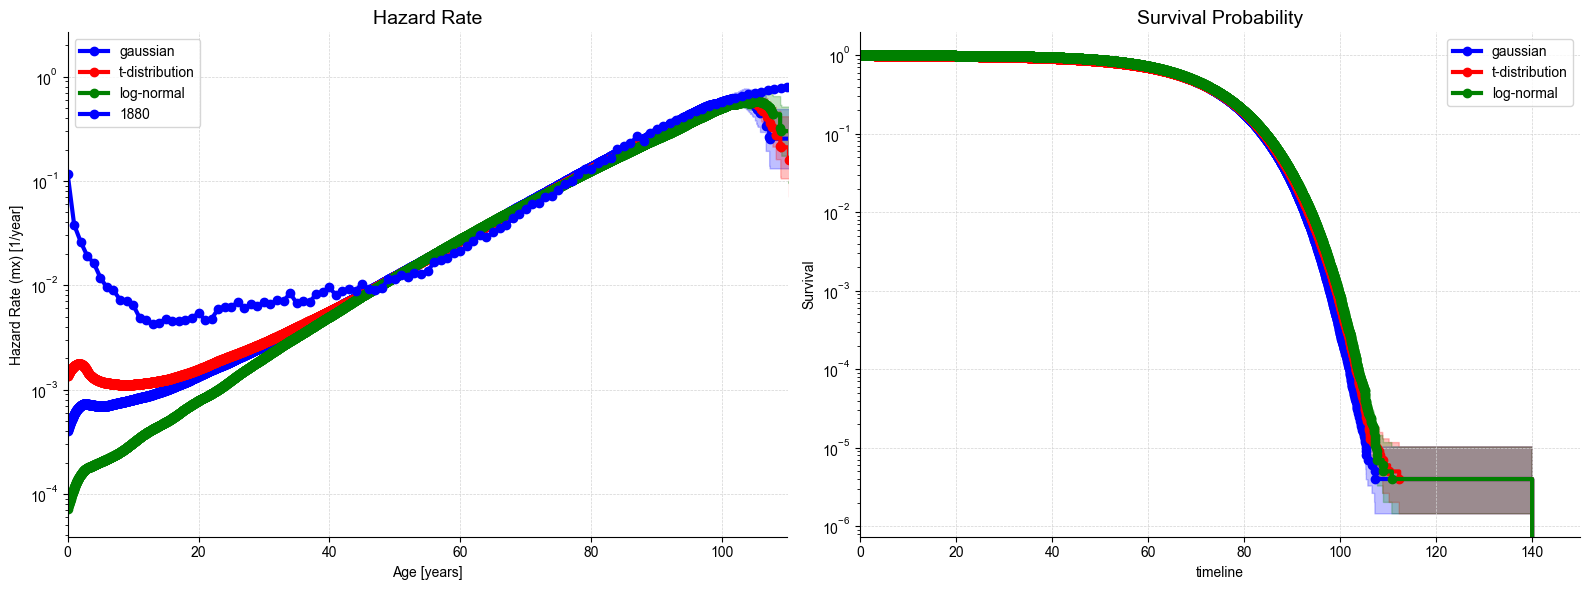

In [102]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

gaussian_plotter = SR_plotting(gaussian_sim)
t_plotter = SR_plotting(t_sim)
log_normal_plotter = SR_plotting(log_normal_sim)

# Left plot: Hazard
gaussian_plotter.plot_hazard(ax=ax1, color='blue', marker='o', label='gaussian', linewidth=3)
t_plotter.plot_hazard(ax=ax1, color='red', marker='o', label='t-distribution', linewidth=3)
log_normal_plotter.plot_hazard(ax=ax1, color='green', marker='o', label='log-normal', linewidth=3)
sweden_period_f.plot_hazard(years = 1880 , ax=ax1, marker='o', linewidth=3)
ax1.set_xlim(0,110)
ax1.set_title('Hazard Rate', fontsize=14)
ax1.legend()

# Right plot: Survival
gaussian_plotter.plot_survival(ax=ax2, color='blue', marker='o', label='gaussian', linewidth=3)
t_plotter.plot_survival(ax=ax2, color='red', marker='o', label='t-distribution', linewidth=3)
log_normal_plotter.plot_survival(ax=ax2, color='green', marker='o', label='log-normal', linewidth=3)
ax2.set_yscale('log')
ax2.set_xlim(0,150)
ax2.set_title('Survival Probability', fontsize=14)
ax2.legend()

plt.tight_layout()

In [103]:
def calculate_variance_components(sim, age_threshold=15, n_bins=70):
    """
    Calculate variance components (noise vs genetic) for a simulation.
    
    Parameters:
    -----------
    sim : simulation object
        Simulation with death_times and params.Xc attributes
    age_threshold : float
        Minimum age to include in analysis
    n_bins : int
        Number of bins to divide Xc into
    
    Returns:
    --------
    dict : Dictionary containing V_noise, V_genetic, V_total, and ratio
    """
    death_times = sim.death_times[sim.death_times > age_threshold]
    Xc_array = sim.params.Xc[sim.death_times > age_threshold]
    
    V_total = death_times.var()
    T_average = death_times.mean()
    
    # Get min and max values of Xc
    Xc_min = Xc_array.min()
    Xc_max = Xc_array.max()
    
    # Create evenly spaced bins
    bins = np.linspace(Xc_min, Xc_max, n_bins + 1)  # n_bins+1 edges to create n_bins bins
    
    # groups: integers 0 … (n_bins-1) telling you which bin
    groups = np.digitize(Xc_array, bins) - 1
    N = len(death_times)
    grand = death_times.mean()
    
    SS_within = 0.0           # ∑ (T_ij − T̄_i)²
    SS_between = 0.0          # ∑ n_i (T̄_i − grand)²
    
    for g in np.unique(groups):
        mask = groups == g
        T_g = death_times[mask]
        n_g = T_g.size
        if n_g < 2:      # skip bins with 0/1 obs — they give no variance info
            continue
        mean_g = T_g.mean()
        SS_within += ((T_g - mean_g)**2).sum()
        SS_between += n_g * (mean_g - grand)**2
    
    V_total = death_times.var(ddof=0)        # population variance
    V_noise = SS_within / N                  # E_G[Var_N(T|G)]
    V_genetic = SS_between / N               # Var_G(E_N[T|G])
    
    return {
        'V_noise': V_noise,
        'V_genetic': V_genetic,
        'V_total': V_total,
        'ratio': V_genetic / V_total
    }

# Calculate and print for gaussian_sim
print("Gaussian simulation:")
gaussian_results = calculate_variance_components(gaussian_sim)
print(f"V_noise: {gaussian_results['V_noise']:.4f}")
print(f"V_genetic: {gaussian_results['V_genetic']:.4f}")
print(f"V_total: {gaussian_results['V_total']:.4f}")
print(f"V_genetic/V_total: {gaussian_results['ratio']:.4f}")
print()

# Calculate and print for t_sim
print("t-test simulation (ν=3):")
t_results = calculate_variance_components(t_sim)
print(f"V_noise: {t_results['V_noise']:.4f}")
print(f"V_genetic: {t_results['V_genetic']:.4f}")
print(f"V_total: {t_results['V_total']:.4f}")
print(f"V_genetic/V_total: {t_results['ratio']:.4f}")

# calculate and print for log_normal_sim
print("Log-normal simulation:")
log_normal_results = calculate_variance_components(log_normal_sim)
print(f"V_noise: {log_normal_results['V_noise']:.4f}")
print(f"V_genetic: {log_normal_results['V_genetic']:.4f}")
print(f"V_total: {log_normal_results['V_total']:.4f}")
print(f"V_genetic/V_total: {log_normal_results['ratio']:.4f}")


Gaussian simulation:
V_noise: 100.4455
V_genetic: 125.1482
V_total: 225.5956
V_genetic/V_total: 0.5547

t-test simulation (ν=3):
V_noise: 99.8845
V_genetic: 138.1687
V_total: 238.0597
V_genetic/V_total: 0.5804
Log-normal simulation:
V_noise: 100.1023
V_genetic: 109.2052
V_total: 209.3087
V_genetic/V_total: 0.5217


### same heritability estimates!

In [77]:
def compute_heritability_anova(sim, cutoff_age=15, n_bootstrap=5):
    death_times = sim.death_times[sim.death_times > cutoff_age]
    death_times = death_times - cutoff_age

    Xc_array = sim.params.Xc[sim.death_times > cutoff_age]

    def _compute_h2(death_times, Xc_array):
        V_total = death_times.var()

        T_average = death_times.mean()

        # Get min and max values of Xc
        Xc_min = Xc_array.min()
        Xc_max = Xc_array.max()

        # Create 50 evenly spaced bins
        bins = np.linspace(Xc_min, Xc_max, 51)  # 51 edges to create 50 bins

        # groups: integers 0 … 49 telling you which bin
        groups = np.digitize(Xc_array, bins) - 1
        N       = len(death_times)
        grand   = death_times.mean()

        SS_within  = 0.0           # ∑ (T_ij − T̄_i)²
        SS_between = 0.0           # ∑ n_i (T̄_i − grand)²

        for g in np.unique(groups):
            mask      = groups == g
            T_g       = death_times[mask]
            n_g       = T_g.size
            if n_g < 2:      # skip bins with 0/1 obs — they give no variance info
                continue
            mean_g     = T_g.mean()
            SS_within += ((T_g - mean_g)**2).sum()
            SS_between+= n_g * (mean_g - grand)**2

        V_total   = death_times.var(ddof=0)        # population variance
        V_noise   = SS_within  / N                 # E_G[Var_N(T|G)]
        V_genetic = SS_between / N                 # Var_G(E_N[T|G])

        return V_genetic/V_total

    # Compute original estimate
    h2_original = _compute_h2(death_times, Xc_array)
    
    # Bootstrap for confidence intervals
    h2_bootstrap = []
    N = len(death_times)
    
    for _ in range(n_bootstrap):
        # Resample with replacement
        indices = np.random.choice(N, size=N, replace=True)
        boot_death_times = death_times[indices]
        boot_Xc_array = Xc_array[indices]
        
        try:
            h2_boot = _compute_h2(boot_death_times, boot_Xc_array)
            h2_bootstrap.append(h2_boot)
        except:
            # Skip bootstrap samples that fail (e.g., due to insufficient data)
            continue
    
    h2_bootstrap = np.array(h2_bootstrap)
    
    # Return original estimate and confidence intervals
    return {
        'h2': h2_original,
        'h2_lower': np.percentile(h2_bootstrap, 2.5),
        'h2_upper': np.percentile(h2_bootstrap, 97.5),
        'h2_std': np.std(h2_bootstrap)
    }




Error bar sizes by age:
Age	t-distribution (lower, upper)	Gaussian (lower, upper)
20	(0.0001, 0.0143)		(0.0006, 0.0000)
25	(0.0008, 0.0395)		(0.0000, 0.0013)
30	(0.0005, 0.0013)		(0.0006, 0.0010)
35	(0.0001, 0.0116)		(0.0006, 0.0009)
40	(0.0017, 0.0126)		(0.0017, 0.0006)
45	(0.0007, 0.0089)		(0.0000, 0.0008)
50	(0.0002, 0.0108)		(0.0012, 0.0003)
55	(0.0017, 0.0359)		(0.0008, 0.0011)
60	(0.0000, 0.0313)		(0.0006, 0.0015)
65	(0.0002, 0.0200)		(0.0008, 0.0016)
70	(0.0010, 0.0023)		(0.0000, 0.0035)
75	(0.0000, 0.0154)		(0.0009, 0.0019)
80	(0.0000, 0.0044)		(0.0003, 0.0037)
85	(0.0000, 0.0089)		(0.0015, 0.0010)
90	(0.0000, 0.0124)		(0.0025, 0.0106)
95	(0.0000, 0.0538)		(0.1393, 0.1378)
100	(0.0693, 0.1720)		(0.3805, 0.2785)


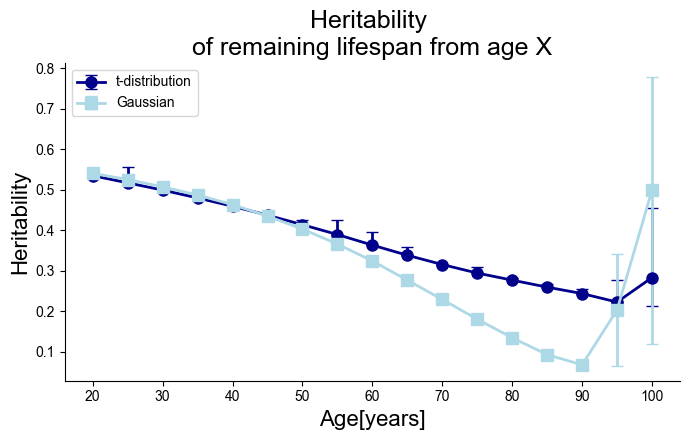

In [83]:

# Compute heritability for different ages for t_sim and gaussian_sim
ages = np.arange(20, 101, 5)
h2_anova_t = []
h2_anova_gaussian = []
for age in ages:
    h2_anova_t.append(compute_heritability_anova(t_sim, cutoff_age=age))
    h2_anova_gaussian.append(compute_heritability_anova(gaussian_sim, cutoff_age=age))

# Extract values and error bars for t_sim
h2_t_values = [result['h2'] for result in h2_anova_t]
h2_t_lower = [result['h2_lower'] for result in h2_anova_t]
h2_t_upper = [result['h2_upper'] for result in h2_anova_t]
# Ensure error bars are non-negative
h2_t_errors = [[max(0, h2_t_values[i] - h2_t_lower[i]) for i in range(len(ages))],
                [max(0, h2_t_upper[i] - h2_t_values[i]) for i in range(len(ages))]]

# Extract values and error bars for gaussian_sim
h2_gaussian_values = [result['h2'] for result in h2_anova_gaussian]
h2_gaussian_lower = [result['h2_lower'] for result in h2_anova_gaussian]
h2_gaussian_upper = [result['h2_upper'] for result in h2_anova_gaussian]
# Ensure error bars are non-negative
h2_gaussian_errors = [[max(0, h2_gaussian_values[i] - h2_gaussian_lower[i]) for i in range(len(ages))],
                        [max(0, h2_gaussian_upper[i] - h2_gaussian_values[i]) for i in range(len(ages))]]

# Print error bar sizes for each age
print("Error bar sizes by age:")
print("Age\tt-distribution (lower, upper)\tGaussian (lower, upper)")
for i, age in enumerate(ages):
    t_lower_err = h2_t_errors[0][i]
    t_upper_err = h2_t_errors[1][i]
    gaussian_lower_err = h2_gaussian_errors[0][i]
    gaussian_upper_err = h2_gaussian_errors[1][i]
    print(f"{age}\t({t_lower_err:.4f}, {t_upper_err:.4f})\t\t({gaussian_lower_err:.4f}, {gaussian_upper_err:.4f})")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(ages, h2_t_values, yerr=h2_t_errors, fmt='o-', color='darkblue', 
            linewidth=2, markersize=8, capsize=4, label='t-distribution')
ax.errorbar(ages, h2_gaussian_values, yerr=h2_gaussian_errors, fmt='s-', color='lightblue', 
            linewidth=2, markersize=8, capsize=4, label='Gaussian')
ax.set_xlabel('Age[years]', fontfamily='Arial', fontsize=16)
ax.set_ylabel('Heritability', fontfamily='Arial', fontsize=16)
ax.set_title('Heritability \nof remaining lifespan from age X', fontfamily='Arial', fontsize=18)
ax.legend(fontsize=14, prop={'family': 'Arial'})
plt.tight_layout()
plt.show()

## heritability to live to age X

### functions

In [104]:
from scipy.stats import norm, multivariate_normal
from scipy.optimize import minimize

def tetrachoric_rho(table):
    """
    table: 2×2 numpy array [[a, b],
                            [c, d]]
           where rows=y1=1,0 and cols=y2=1,0
    """
    n = table.sum()
    p11, p10 = table[0,0]/n, table[0,1]/n
    p01, p00 = table[1,0]/n, table[1,1]/n

    # thresholds from marginals
    t1 = norm.ppf(1 - (p11 + p10))
    t2 = norm.ppf(1 - (p11 + p01))

    def neg_loglik(rho):
        # build the bivariate normal with correlation rho
        mvn = multivariate_normal(mean=[0,0], cov=[[1, rho],[rho, 1]])
        # P(L1 <= t1, L2 <= t2)
        p00_hat = mvn.cdf([t1, t2])
        # P(L1 <= t1) = Φ(t1),   P(L2 <= t2) = Φ(t2)
        F1, F2 = norm.cdf(t1), norm.cdf(t2)
        # other three cells by inclusion-exclusion
        p01_hat = F1 - p00_hat    # L1<=t1, L2>t2
        p10_hat = F2 - p00_hat    # L1>t1, L2<=t2
        p11_hat = 1 - (p00_hat + p01_hat + p10_hat)
        probs = np.clip([p11_hat, p10_hat, p01_hat, p00_hat], 1e-9, 1)
        return -np.dot(table.flatten(), np.log(probs))

    # optimize rho in (–0.999,0.999)
    res = minimize(lambda x: neg_loglik(x[0]),
                   x0=[0.0],
                   bounds=[(-0.999, 0.999)])
    return float(res.x[0])

def compute_rho(df, cutoff):
    y1 = (df['death1'] >= cutoff).astype(int)
    y2 = (df['death2'] >= cutoff).astype(int)
    tab = pd.crosstab(y1, y2).reindex(index=[1,0], columns=[1,0], fill_value=0)
    return tetrachoric_rho(tab.values)

def liability_heritability(mz_df, dz_df, cutoff):
    # 1. tetrachoric correlations
    rho_MZ = compute_rho(mz_df, cutoff)
    rho_DZ = compute_rho(dz_df, cutoff)

    # 2. liability-scale h²
    h_L2 = 2*(rho_MZ - rho_DZ)

    # 3. prevalence in your combined sample
    all_y = pd.concat([
        (mz_df[['death1','death2']] >= cutoff).stack(),
        (dz_df[['death1','death2']] >= cutoff).stack()
    ])
    K = all_y.mean()

    # 4. observed-scale h²
    t    = norm.ppf(1-K)
    h_O2 = h_L2 * norm.pdf(t)**2 / (K*(1-K))
    return h_L2, h_O2, K


# same but with error bars
def liability_heritability_bootstrap(mz_df, dz_df, cutoff, B=1000, seed=0,
                                     return_boot=False, clip_unit=True):
    """
    Bootstrap CIs for h_L2 and h_O2 at a given cutoff.

    Returns:
      dict with point estimates, SE, normal-approx 95% CI, percentile 95% CI,
      and same for rho_MZ and rho_DZ. Optionally returns bootstrap draws.
    """
    rng = np.random.default_rng(seed)

    def point_est(df_mz, df_dz):
        # tetrachorics
        rho_MZ = compute_rho(df_mz, cutoff)
        rho_DZ = compute_rho(df_dz, cutoff)
        # liability-scale h^2
        h_L2 = 2*(rho_MZ - rho_DZ)
        # observed-scale h^2 (using combined prevalence)
        all_y = pd.concat([
            (df_mz[['death1','death2']] >= cutoff).stack(),
            (df_dz[['death1','death2']] >= cutoff).stack()
        ])
        K = all_y.mean()
        t = norm.ppf(1 - K)
        h_O2 = h_L2 * norm.pdf(t)**2 / (K*(1-K))
        if clip_unit:
            h_L2 = float(np.clip(h_L2, 0.0, 1.0))
            h_O2 = float(np.clip(h_O2, 0.0, 1.0))
        return rho_MZ, rho_DZ, h_L2, h_O2, float(K)

    # point estimates
    rho_MZ, rho_DZ, hL2_hat, hO2_hat, K_hat = point_est(mz_df, dz_df)

    # bootstrap draws
    n_mz, n_dz = len(mz_df), len(dz_df)
    rhoMZ_bs, rhoDZ_bs, hL2_bs, hO2_bs = [], [], [], []
    for _ in range(B):
        mz_b = mz_df.iloc[rng.integers(0, n_mz, n_mz)]
        dz_b = dz_df.iloc[rng.integers(0, n_dz, n_dz)]
        rMZ_b, rDZ_b, hL2_b, hO2_b, _ = point_est(mz_b, dz_b)
        rhoMZ_bs.append(rMZ_b)
        rhoDZ_bs.append(rDZ_b)
        hL2_bs.append(hL2_b)
        hO2_bs.append(hO2_b)

    def se(x): return float(np.std(x, ddof=1))
    def pct_ci(x): 
        lo, hi = np.percentile(x, [2.5, 97.5])
        return float(lo), float(hi)
    def norm95(mu, s):
        return float(mu - 1.96*s), float(mu + 1.96*s)

    # assemble
    out = {
        # point estimates
        "K": K_hat,
        "rho_MZ": float(rho_MZ),
        "rho_DZ": float(rho_DZ),
        "h_L2": float(hL2_hat),
        "h_O2": float(hO2_hat),

        # standard errors
        "rho_MZ_se": se(rhoMZ_bs),
        "rho_DZ_se": se(rhoDZ_bs),
        "h_L2_se": se(hL2_bs),
        "h_O2_se": se(hO2_bs),

        # normal-approx 95% CIs using SE
        "rho_MZ_ci_norm": norm95(rho_MZ, se(rhoMZ_bs)),
        "rho_DZ_ci_norm": norm95(rho_DZ, se(rhoDZ_bs)),
        "h_L2_ci_norm": norm95(hL2_hat, se(hL2_bs)),
        "h_O2_ci_norm": norm95(hO2_hat, se(hO2_bs)),

        # percentile 95% CIs
        "rho_MZ_ci_pct": pct_ci(rhoMZ_bs),
        "rho_DZ_ci_pct": pct_ci(rhoDZ_bs),
        "h_L2_ci_pct": pct_ci(hL2_bs),
        "h_O2_ci_pct": pct_ci(hO2_bs),
    }
    if return_boot:
        out["boot"] = {
            "rho_MZ": np.array(rhoMZ_bs),
            "rho_DZ": np.array(rhoDZ_bs),
            "h_L2": np.array(hL2_bs),
            "h_O2": np.array(hO2_bs),
        }
    return out

def plot_heritability_comparison(ax1, ax2=None, survived_to=15, plot_medians=True, mz_sim=None, dz_sim=None, **kwargs):
    """
    Plot liability-scale and observed-scale heritability for different age cutoffs.
    
    Parameters:
    ax1: matplotlib axis for liability-scale heritability plot
    ax2: matplotlib axis for observed-scale heritability plot (optional)
    survived_to (int): Minimum age for survival filter (default: 15)
    plot_medians (bool): Whether to plot median lifespan lines (default: True)
    mz_sim: MZ twin simulation data (default: Xc_sim_MZ)
    dz_sim: DZ twin simulation data (default: Xc_sim_DZ)
    """
    
    filter_age = survived_to
    ages = range(filter_age + 2, 111, 3)

    # Calculate twin death tables
    mz_table = ca.calc_twin_death_table(sim = mz_sim , filter_age = filter_age)
    dz_table = ca.calc_twin_death_table(sim = dz_sim, filter_age = filter_age)

    h2_liability = []
    h2_observed = []

    for i, cutoff in enumerate(ages):
        print(f"\nProcessing cutoff {cutoff} (iteration {i+1}/{len(ages)})")
        
        # Check survival counts for this cutoff
        mz_survived1 = (mz_table['death1'] >= cutoff).sum()
        mz_survived2 = (mz_table['death2'] >= cutoff).sum()
        dz_survived1 = (dz_table['death1'] >= cutoff).sum()
        dz_survived2 = (dz_table['death2'] >= cutoff).sum()
        
        print(f"  MZ survivors twin1: {mz_survived1}/{len(mz_table)} ({mz_survived1/len(mz_table):.3f})")
        print(f"  MZ survivors twin2: {mz_survived2}/{len(mz_table)} ({mz_survived2/len(mz_table):.3f})")
        print(f"  DZ survivors twin1: {dz_survived1}/{len(dz_table)} ({dz_survived1/len(dz_table):.3f})")
        print(f"  DZ survivors twin2: {dz_survived2}/{len(dz_table)} ({dz_survived2/len(dz_table):.3f})")
        
        # Check if we have enough variation for correlation calculation
        if mz_survived1 == 0 or mz_survived1 == len(mz_table) or dz_survived1 == 0 or dz_survived1 == len(dz_table):
            print(f"  WARNING: No variation in survival at cutoff {cutoff}, skipping...")
            continue
            
        try:
            h_L2, h_O2, K = liability_heritability(mz_table, dz_table, cutoff)
            print(f"  h_L2: {h_L2}, h_O2: {h_O2}, K: {K}")
            h2_liability.append(h_L2)
            h2_observed.append(h_O2)
        except Exception as e:
            print(f"  ERROR at cutoff {cutoff}: {e}")
            print(f"  Skipping this cutoff...")
            continue
    
    print(f"\nSuccessfully calculated heritability for {len(h2_liability)} cutoffs")
    
    if len(h2_liability) == 0:
        print("No valid heritability calculations - cannot plot")
        return
    
    # Adjust ages list to match successful calculations
    valid_ages = ages[:len(h2_liability)]
    
    # Plot liability-scale heritability on ax1
    if len(h2_liability) > 1:
        ax1.plot(valid_ages[1:], h2_liability[1:], 'o-', linewidth=2, markersize=8, **kwargs)
    else:
        ax1.plot(valid_ages, h2_liability, 'o', markersize=8, **kwargs)
    ax1.set_xlabel('Age [years]', fontsize=16)
    ax1.set_ylabel('Liability-scale heritability (h²_L)', fontsize=16)
    ax1.set_title('Liability-scale heritability\nof survival to age x', fontsize=18)
    ax1.set_ylim(0, 1)
    
    # Plot median lines if flag is True
    if plot_medians:
        ax1.axvline(x=mz_sim.median_t, linestyle='--', alpha=0.7)
        ax1.text(mz_sim.median_t+1, 0.21, 'median lifespan', fontsize=14)

    # Plot observed-scale heritability on ax2 if provided
    if ax2 is not None:
        if len(h2_observed) > 1:
            ax2.plot(valid_ages[1:], h2_observed[1:], 'o-', linewidth=2, markersize=8, **kwargs)
        else:
            ax2.plot(valid_ages, h2_observed, 'o', markersize=8, **kwargs)
        ax2.set_xlabel('Age [years]', fontsize=16)
        ax2.set_ylabel('Observed-scale heritability (h²_O)', fontsize=16)
        ax2.set_title('Observed-scale heritability\nof survival to age x', fontsize=18)
        
        # Plot median lines if flag is True
        if plot_medians:
            ax2.axvline(x=mz_sim.median_t, color='darkred', linestyle='--', alpha=0.7)
            ax2.text(mz_sim.median_t+1, 0.02, 'median lifespan', fontsize=14, color='darkred')

In [105]:
# Use the same parameters as in the earlier cells
n = int(1e6)

# Adjust Xc to match baseline
danish_dict_adjusted = danish_dict.copy()
danish_dict_adjusted['Xc'] = danish_dict_adjusted['Xc']
nu = 4

# Gaussian distribution simulations
print("Running Gaussian distribution simulations...")
sim_dict_gauss_MZ = utils.create_param_distribution_dict(
    params='Xc', 
    std=danish_Xc_std, 
    n=n, 
    family='MZ', 
    params_dict=danish_dict_adjusted,
    dist_type='gaussian'
)
gaussian_sim_MZ = utils.create_sr_simulation(params_dict=sim_dict_gauss_MZ, n=n, parallel=True)
print('done Gaussian MZ')

sim_dict_gauss_DZ = utils.create_param_distribution_dict(
    params='Xc', 
    std=danish_Xc_std, 
    n=n, 
    family='DZ', 
    params_dict=danish_dict_adjusted,
    dist_type='gaussian'
)
gaussian_sim_DZ = utils.create_sr_simulation(params_dict=sim_dict_gauss_DZ, n=n, parallel=True)
print('done Gaussian DZ')

# t-distribution simulations
print("\nRunning t-distribution simulations...")
sim_dict_t_MZ = utils.create_param_distribution_dict(
    params='Xc', 
    std=danish_Xc_std, 
    n=n, 
    family='MZ', 
    params_dict=danish_dict_adjusted,
    dist_type='t-test',
    nu=nu
)
t_sim_MZ = utils.create_sr_simulation(params_dict=sim_dict_t_MZ, n=n, parallel=True)
print('done t-distribution MZ')

sim_dict_t_DZ = utils.create_param_distribution_dict(
    params='Xc', 
    std=danish_Xc_std, 
    n=n, 
    family='DZ', 
    params_dict=danish_dict_adjusted,
    dist_type='t-test',
    nu=nu
)
t_sim_DZ = utils.create_sr_simulation(params_dict=sim_dict_t_DZ, n=n, parallel=True)
print('done t-distribution DZ')

# Log-normal distribution simulations
print("\nRunning log-normal distribution simulations...")
sim_dict_lognormal_MZ = utils.create_param_distribution_dict(
    params='Xc', 
    std=danish_Xc_std, 
    n=n, 
    family='MZ', 
    params_dict=danish_dict_adjusted,
    dist_type='lognormal'
)
log_normal_sim_MZ = utils.create_sr_simulation(params_dict=sim_dict_lognormal_MZ, n=n, parallel=True)
print('done log-normal MZ')

sim_dict_lognormal_DZ = utils.create_param_distribution_dict(
    params='Xc', 
    std=danish_Xc_std, 
    n=n, 
    family='DZ', 
    params_dict=danish_dict_adjusted,
    dist_type='lognormal'
)
log_normal_sim_DZ = utils.create_sr_simulation(params_dict=sim_dict_lognormal_DZ, n=n, parallel=True)
print('done log-normal DZ')


Running Gaussian distribution simulations...
done Gaussian MZ
done Gaussian DZ

Running t-distribution simulations...
done t-distribution MZ
done t-distribution DZ

Running log-normal distribution simulations...
done log-normal MZ
done log-normal DZ



Processing cutoff 17 (iteration 1/32)
  MZ survivors twin1: 489527/490421 (0.998)
  MZ survivors twin2: 489663/490421 (0.998)
  DZ survivors twin1: 487772/488737 (0.998)
  DZ survivors twin2: 487766/488737 (0.998)
  h_L2: 0.5282873269316435, h_O2: 0.009902360876320106, K: 0.998167813570435

Processing cutoff 20 (iteration 2/32)
  MZ survivors twin1: 488093/490421 (0.995)
  MZ survivors twin2: 488111/490421 (0.995)
  DZ survivors twin1: 486134/488737 (0.995)
  DZ survivors twin2: 486067/488737 (0.995)
  h_L2: 0.5296115614532331, h_O2: 0.022471106055368343, K: 0.9949390190347217

Processing cutoff 23 (iteration 3/32)
  MZ survivors twin1: 486110/490421 (0.991)
  MZ survivors twin2: 486236/490421 (0.991)
  DZ survivors twin1: 484082/488737 (0.990)
  DZ survivors twin2: 484048/488737 (0.990)
  h_L2: 0.6067417497433496, h_O2: 0.04056387049878041, K: 0.9908901321339355

Processing cutoff 26 (iteration 4/32)
  MZ survivors twin1: 483782/490421 (0.986)
  MZ survivors twin2: 483875/490421 (0.9

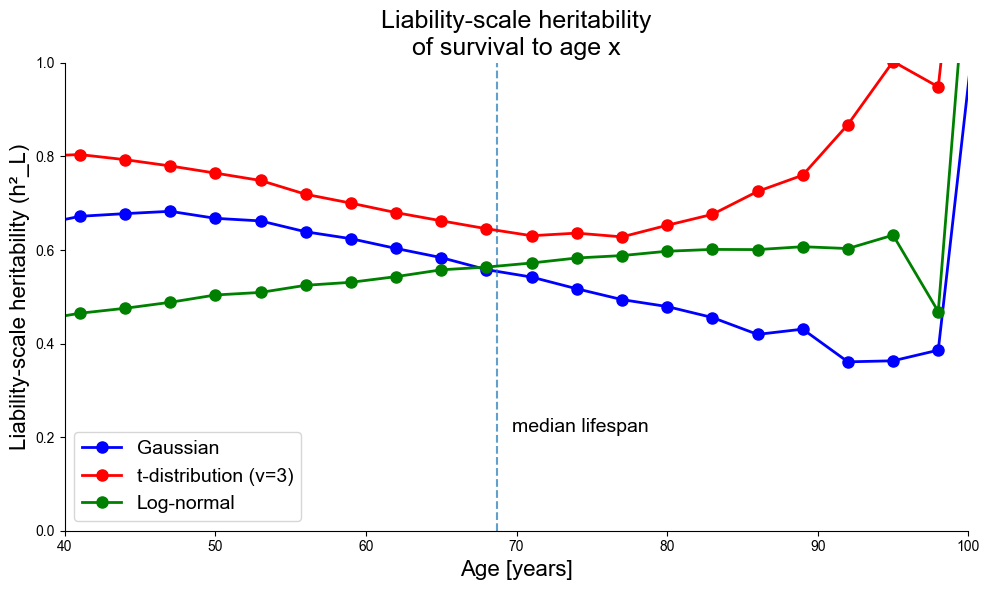

In [107]:
# Create figure for comparing Gaussian, t-distribution, and log-normal heritability
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Gaussian simulations
plot_heritability_comparison(
    ax1=ax1,
    survived_to=15,
    plot_medians=True,
    mz_sim=gaussian_sim_MZ,
    dz_sim=gaussian_sim_DZ,
    label='Gaussian',
    color='blue'
)

# Plot t-distribution simulations
plot_heritability_comparison(
    ax1=ax1,
    survived_to=15,
    plot_medians=False,  # Only show median once
    mz_sim=t_sim_MZ,
    dz_sim=t_sim_DZ,
    label='t-distribution (ν=3)',
    color='red'
)

# Plot log-normal simulations
plot_heritability_comparison(
    ax1=ax1,
    survived_to=15,
    plot_medians=False,  # Only show median once
    mz_sim=log_normal_sim_MZ,
    dz_sim=log_normal_sim_DZ,
    label='Log-normal',
    color='green'
)

ax1.legend(fontsize=14)
ax1.set_xlim(40,100)
ax1.set_ylim(0,1)
plt.tight_layout()
plt.show()


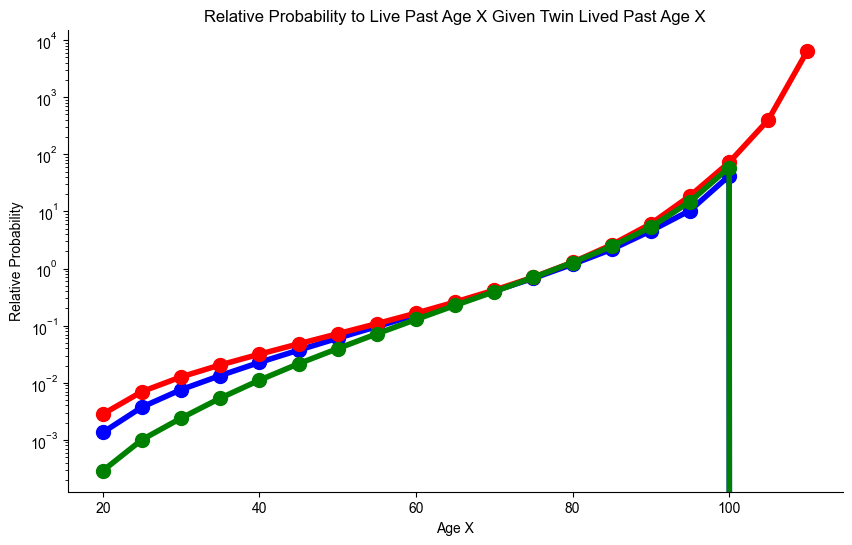

In [108]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ages = np.arange(20,111,5)
hp.plot_relative_survival_prob_to_age(sim=gaussian_sim_MZ, ax=ax1, filter_age=15, ages=ages, color='blue', marker = 'o', markersize = 10, label = 'gaussian', linewidth=4)
hp.plot_relative_survival_prob_to_age(sim=t_sim_MZ, ax=ax1, filter_age=15, ages=ages, color='red', marker = 'o', markersize = 10, label = 't-distribution', linewidth=4)
hp.plot_relative_survival_prob_to_age(sim=log_normal_sim_MZ, ax=ax1, filter_age=15, ages=ages, color='green', marker = 'o', markersize = 10, label = 'log-normal', linewidth=4)
ax1.set_yscale('log')


## What about maximum lifespan?

Running Gaussian simulation...
10
18
33
61
112
206
379
695
1274
2335
4281
7847
14384
26366
48329
88586
162377
297635
545559
Skipping population size 1000000 - larger than available data
Running t-test simulation with nu=3...
10
18
33
61
112
206
379
695
1274
2335
4281
7847
14384
26366
48329
88586
162377
297635
545559
Skipping population size 1000000 - larger than available data
Running t-test simulation with nu=4...
10
18
33
61
112
206
379
695
1274
2335
4281
7847
14384
26366
48329
88586
162377
297635
545559
Skipping population size 1000000 - larger than available data
Running t-test simulation with nu=5...
10
18
33
61
112
206
379
695
1274
2335
4281
7847
14384
26366
48329
88586
162377
297635
545559
Skipping population size 1000000 - larger than available data
Running t-test simulation with nu=10...
10
18
33
61
112
206
379
695
1274
2335
4281
7847
14384
26366
48329
88586
162377
297635
545559
Skipping population size 1000000 - larger than available data


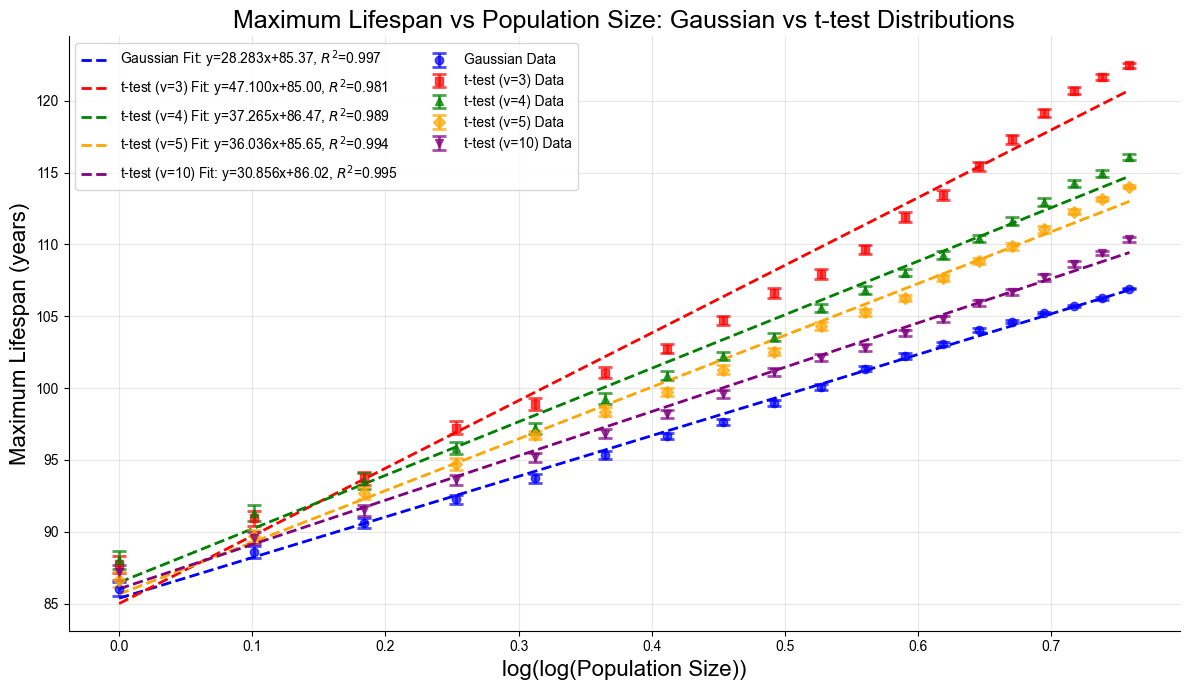

In [92]:
n_sim = int(1e6)
import sys
sys.path.append('../extrinsic_mortality_paper/data')
import model_param_calibrations as mcal

danish_dict = mcal.sr_denmark_dict.copy()
danish_Xc_std = mcal.sr_calibrations['denmark']['Xc_std']
        
# Adjust Xc
danish_dict['Xc'] = 0.85 * danish_dict['Xc']

# Define nu parameters for t-test distribution
nu_values = [3, 4, 5, 10]

# Function to run simulation and calculate max lifespans
def calculate_max_lifespans(dist_type, nu=None):
    # Create parameter distributions
    danish_param_dist = utils.create_param_distribution_dict(
        params_dict=danish_dict,
        params='Xc',
        std=danish_Xc_std,
        n=n_sim,
        family='None',
        dist_type=dist_type,
        nu=nu
    )
    
    # Simulate
    sim = utils.create_sr_simulation(params_dict=danish_param_dist, n=n_sim, parallel=True)
    
    pop_size = np.logspace(1, 6, 20)
    max_lifespans = []
    max_lifespans_sem = []
    
    death_times = sim.death_times[sim.death_times <= 130]
    shuffled_death_times = np.random.permutation(death_times)
    
    for pop in pop_size:
        pop = int(pop)
        max_values = []
        
        if pop > len(shuffled_death_times):
            print(f"Skipping population size {pop} - larger than available data")
            continue
        
        if pop == len(shuffled_death_times):
            max_values = [np.max(shuffled_death_times)]
        else:
            for i in range(100):
                max_start_idx = len(shuffled_death_times) - pop
                start_idx = (i * pop) % max_start_idx if max_start_idx > 0 else 0
                sampled_deaths = shuffled_death_times[start_idx:start_idx + pop]
                max_values.append(np.max(sampled_deaths))
        
        max_lifespans.append(np.mean(max_values))
        max_lifespans_sem.append(np.std(max_values) / np.sqrt(len(max_values)))
        print(pop)
    
    return sim, pop_size[:len(max_lifespans)], max_lifespans, max_lifespans_sem

# Run simulations for Gaussian
print("Running Gaussian simulation...")
gaussian_sim, pop_size_gauss, max_lifespans_gauss, max_lifespans_sem_gauss = calculate_max_lifespans('gaussian')

# Run simulations for all t-test distributions
t_results = {}
for nu in nu_values:
    print(f"Running t-test simulation with nu={nu}...")
    t_sim, pop_size_t, max_lifespans_t, max_lifespans_sem_t = calculate_max_lifespans('t-test', nu=nu)
    t_results[nu] = {
        'sim': t_sim,
        'pop_size': pop_size_t,
        'max_lifespans': max_lifespans_t,
        'max_lifespans_sem': max_lifespans_sem_t
    }

# Store last t_sim as hum_sim for compatibility with later cells
hum_sim = t_results[nu_values[-1]]['sim']

# Plotting
import matplotlib.font_manager as fm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

plt.rcParams['font.family'] = 'Arial'

fig, ax = plt.subplots(figsize=(12, 7))

# Function to fit and plot
def fit_and_plot(pop_size, max_lifespans, max_lifespans_sem, label, color, marker):
    x_array = np.log10(np.log10(pop_size))
    y_array = np.array(max_lifespans)
    yerr_array = np.array(max_lifespans_sem)
    
    # Linear regression
    X = x_array.reshape(-1, 1)
    reg = LinearRegression()
    reg.fit(X, y_array)
    y_pred = reg.predict(X)
    r2 = r2_score(y_array, y_pred)
    
    slope = reg.coef_[0]
    intercept = reg.intercept_
    
    # Plot data
    ax.errorbar(x_array, y_array, yerr=yerr_array, 
                marker=marker, capsize=5, capthick=2, linewidth=2, 
                label=f'{label} Data', linestyle='None', color=color, alpha=0.7)
    
    # Plot regression line
    x_fit = np.linspace(x_array.min(), x_array.max(), 100)
    y_fit = reg.predict(x_fit.reshape(-1, 1))
    ax.plot(x_fit, y_fit, color=color, linewidth=2, linestyle='--',
            label=f'{label} Fit: y={slope:.3f}x+{intercept:.2f}, $R^2$={r2:.3f}')
    
    return slope, intercept, r2

# Define colors and markers for each distribution
colors = ['blue', 'red', 'green', 'orange', 'purple']
markers = ['o', 's', '^', 'D', 'v']

# Fit and plot Gaussian
fit_and_plot(pop_size_gauss, max_lifespans_gauss, max_lifespans_sem_gauss, 
             'Gaussian', colors[0], markers[0])

# Fit and plot all t-test distributions
for i, nu in enumerate(nu_values):
    result = t_results[nu]
    fit_and_plot(result['pop_size'], result['max_lifespans'], result['max_lifespans_sem'], 
                 f't-test (ν={nu})', colors[i+1], markers[i+1])

ax.set_xlabel('log(log(Population Size))', fontsize=16)
ax.set_ylabel('Maximum Lifespan (years)', fontsize=16)
ax.set_title('Maximum Lifespan vs Population Size: Gaussian vs t-test Distributions', fontsize=18)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='best', ncol=2)

plt.tight_layout()
plt.show()


In [95]:
gaussian_sim.params.beta[0]**2 / (gaussian_sim.params.eta[0]*gaussian_sim.params.Xc[0])

451.1277146853615

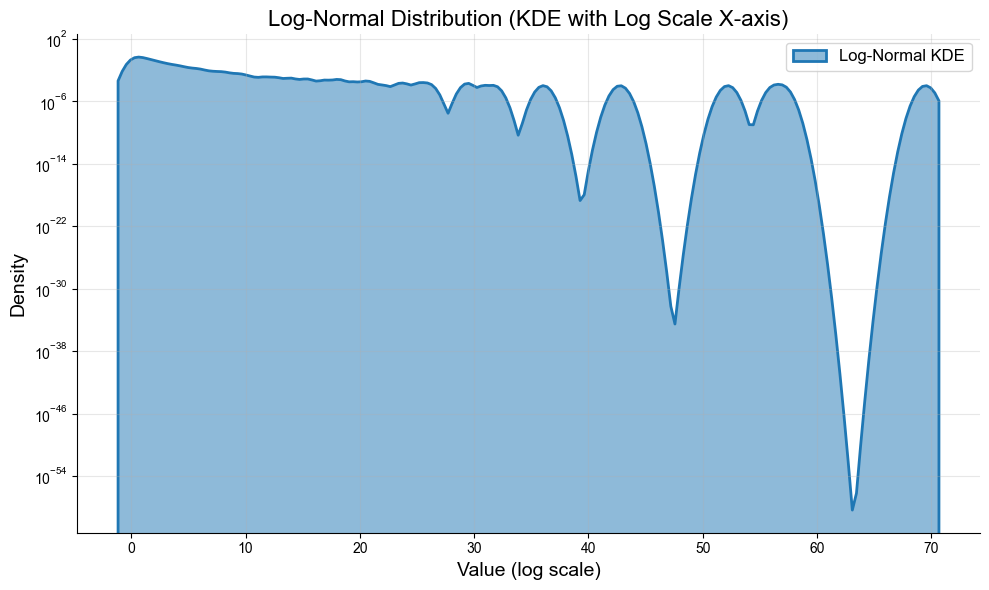

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm
import seaborn as sns

# Generate log-normal distribution samples
mu = 0  # Mean of underlying normal distribution
sigma = 1  # Standard deviation of underlying normal distribution
samples = np.random.lognormal(mean=mu, sigma=sigma, size=10000)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot KDE with log scale on x-axis
sns.kdeplot(samples, ax=ax, fill=True, alpha=0.5, linewidth=2, label='Log-Normal KDE')

# Set log scale for x-axis
ax.set_yscale('log')

# Labels and title
ax.set_xlabel('Value (log scale)', fontsize=14)
ax.set_ylabel('Density', fontsize=14)
ax.set_title('Log-Normal Distribution (KDE with Log Scale X-axis)', fontsize=16)
ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()
